In [1]:
# load master dataset
import pandas as pd
import numpy as np

df = pd.read_csv('data/processed/master_dataset_merged.csv')

# Quick check: How many rows and columns?
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")

Dataset shape: (276, 20)

Column names: ['race_number', 'race_name', 'race_date', 'primary_sponsor', 'finish_position', 'laps_led', 'merge_key', 'reddit_mention_count', 'youtube_total_view_count', 'youtube_total_like_count', 'youtube_total_comment_count', 'youtube_total_duration_seconds', 'num_youtube_videos', 'news_total_mentions', 'news_weighted_mentions', 'news_passing_mentions', 'news_primary_mentions', 'news_secondary_mentions', 'driver_search_interest', 'sponsor_search_interest']


In [2]:
# Keep only the 5 tracked sponsors — each already maps to exactly one car per
# race in the source data, so this gives one clean datapoint per car, no
# aggregation needed. "Other/Unknown" pools ~35 unrelated cars per race behind
# a single row (finish_position taken via min/mean), which distorts any metric
# built from it — drop it rather than aggregate it.
df = df[df['primary_sponsor'] != 'Other/Unknown'].reset_index(drop=True)

print(f"Dataset shape after dropping Other/Unknown: {df.shape}")
print(df['primary_sponsor'].value_counts())

Dataset shape after dropping Other/Unknown: (223, 20)
primary_sponsor
Busch Light                  53
Castrol                      53
Love's Travel Stops          53
Progressive                  52
Cheddar's Scratch Kitchen    12
Name: count, dtype: int64


## Distribution check: predictor histograms

Before fitting anything, look at the shape of each candidate predictor. A histogram
answers three questions at a glance: is it skewed (candidate for a log transform),
is it zero-inflated (candidate for a two-part model), and does it have extreme
outliers (candidate for winsorizing). We build one reusable plotting function so
every panel is visually consistent, then run it across all numeric predictors.

In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

# --- design tokens (single sequential hue + recessive chrome) ---
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"
FILL = "#86b6ef"      # sequential step 250 (fill)
FILL_EDGE = "#2a78d6" # sequential step 450 (edge / mean line)
SURFACE = "#fcfcfb"

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Segoe UI", "Helvetica Neue", "Arial", "sans-serif"]


def plot_histogram(data: pd.DataFrame, column: str, ax=None, bins=30, log=False):
    """One consistently-styled histogram panel for a single numeric predictor."""
    series = data[column].dropna()
    values = np.log1p(series) if log else series

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3.2), dpi=150)

    ax.set_facecolor(SURFACE)
    ax.hist(values, bins=bins, color=FILL, edgecolor=SURFACE, linewidth=0.5, zorder=2)

    mean_val, median_val = values.mean(), values.median()
    ax.axvline(mean_val, color=FILL_EDGE, linewidth=1.5, zorder=3)
    ax.axvline(median_val, color=INK_SECONDARY, linewidth=1, linestyle="--", zorder=3)

    ymax = ax.get_ylim()[1]
    ax.text(mean_val, ymax * 1.02, "mean", color=FILL_EDGE, fontsize=8,
            ha="center", va="bottom")
    ax.text(median_val, ymax * 1.14, "median", color=INK_SECONDARY, fontsize=8,
            ha="center", va="bottom")

    # skew + normality read, annotated directly rather than left to the eye
    skew = stats.skew(series)
    if 3 <= len(series) <= 5000:
        _, p = stats.shapiro(series)
        stat_label = f"skew={skew:.2f}  |  Shapiro–Wilk p={p:.3f}"
    else:
        stat_label = f"skew={skew:.2f}"
   
    ax.text(0.02, 0.96, stat_label, transform=ax.transAxes, fontsize=7.5,
            color=INK_MUTED, ha="left", va="top")

    title = column.replace("_", " ")
    if log:
        title += "  (log1p)"
    ax.set_title(title, fontsize=10, color=INK_PRIMARY, loc="left", pad=8)

    ax.grid(axis="y", color=GRIDLINE, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(BASELINE)
    ax.tick_params(axis="both", colors=INK_MUTED, labelsize=8, length=0)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=4))

    return ax

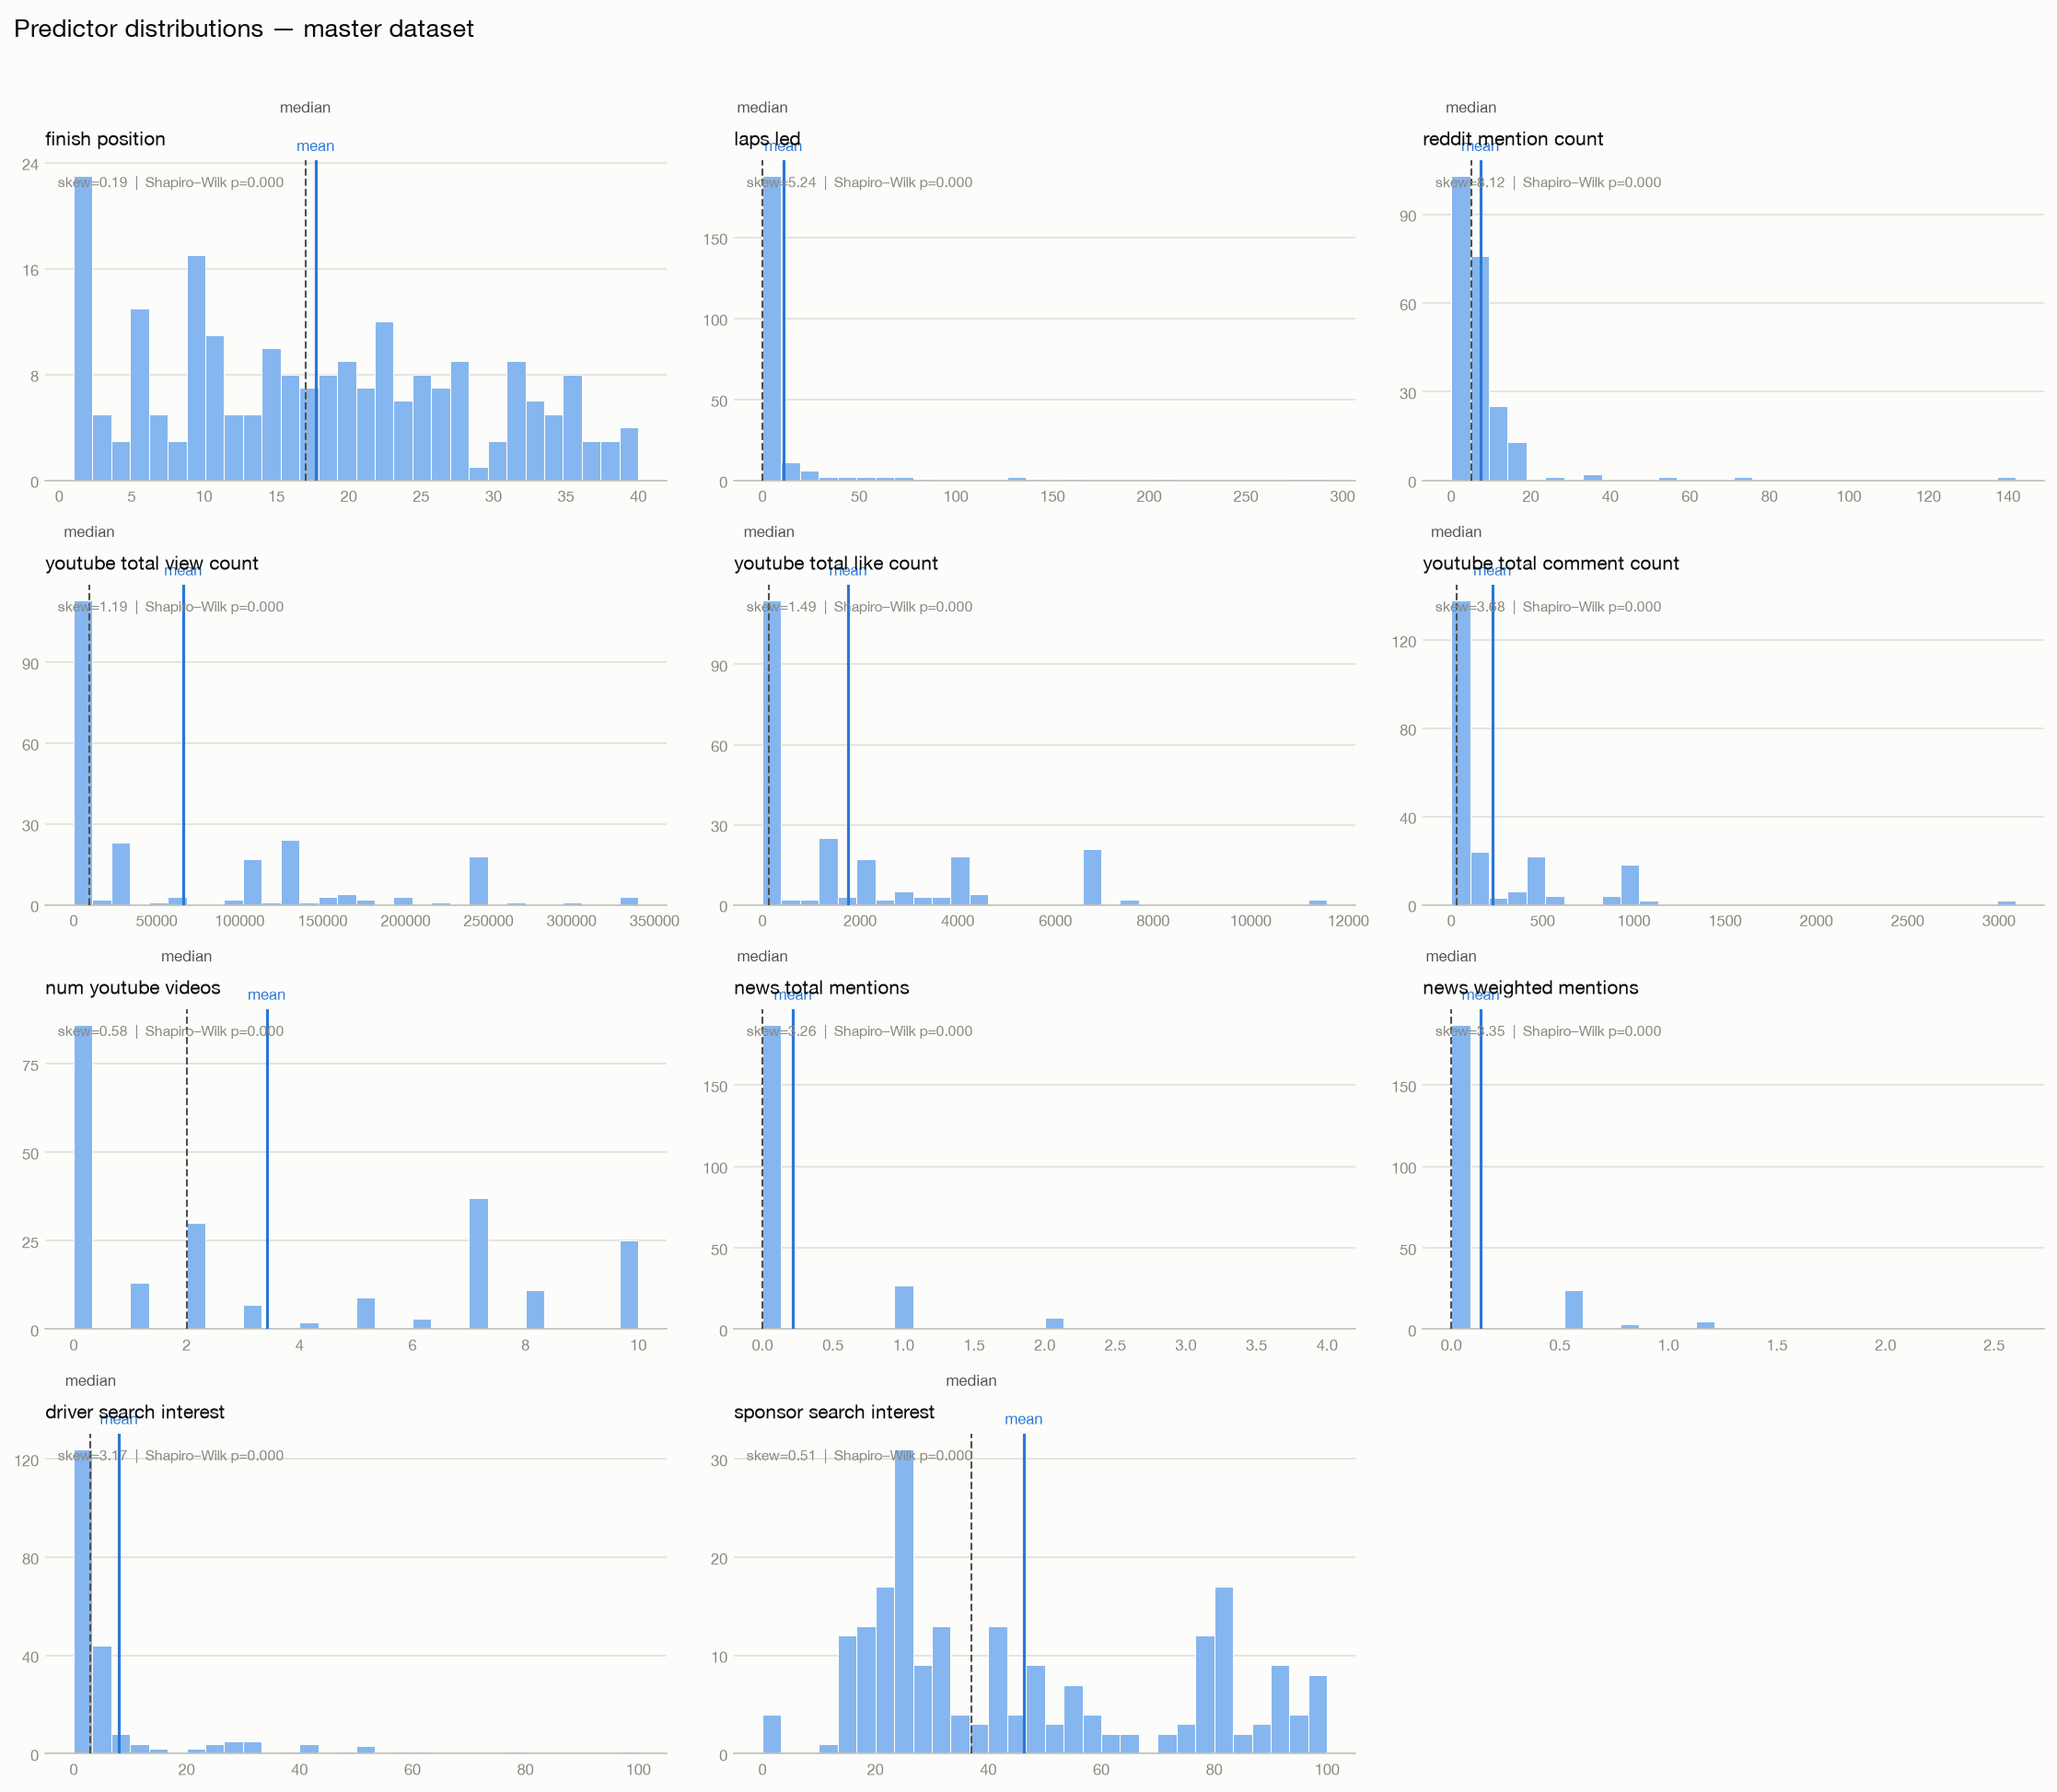

In [4]:
predictor_cols = [
    "finish_position", "laps_led", "reddit_mention_count",
    "youtube_total_view_count", "youtube_total_like_count",
    "youtube_total_comment_count", "num_youtube_videos",
    "news_total_mentions", "news_weighted_mentions",
    "driver_search_interest", "sponsor_search_interest",
]

n_cols = 3
n_rows = int(np.ceil(len(predictor_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.2 * n_rows), dpi=150)
fig.patch.set_facecolor(SURFACE)
axes = axes.flatten()

for ax, col in zip(axes, predictor_cols):
    plot_histogram(df, col, ax=ax)

for ax in axes[len(predictor_cols):]:
    ax.axis("off")

fig.suptitle("Predictor distributions — master dataset", fontsize=13,
             color=INK_PRIMARY, x=0.01, ha="left", y=1.01)
fig.tight_layout()
plt.show()

In [5]:
# Group by sponsor and calculate key statistics
performance_stats = df.groupby('primary_sponsor').agg({
    'finish_position': ['mean', 'median', 'std', 'min', 'max'],
    'laps_led': ['sum', 'mean'],
}).round(2)

# Flatten column names for readability
performance_stats.columns = ['_'.join(col) for col in performance_stats.columns]
performance_stats = performance_stats.reset_index()

print("Performance Statistics by Sponsor:")
print(performance_stats)

Performance Statistics by Sponsor:
             primary_sponsor  finish_position_mean  finish_position_median  \
0                Busch Light                 17.23                    16.0   
1                    Castrol                 18.81                    16.0   
2  Cheddar's Scratch Kitchen                 24.92                    26.0   
3        Love's Travel Stops                 20.96                    21.0   
4                Progressive                 12.08                     8.0   

   finish_position_std  finish_position_min  finish_position_max  \
0                10.39                    1                   40   
1                11.54                    2                   39   
2                 7.44                    9                   36   
3                 8.63                    2                   39   
4                11.37                    1                   38   

   laps_led_sum  laps_led_mean  
0           143           2.70  
1           382      

In [6]:
# Exposure statistics by sponsor
exposure_stats = df.groupby('primary_sponsor').agg({
    'reddit_mention_count': ['sum', 'mean', 'std','median'],
    'youtube_total_view_count': ['sum', 'mean','std','median'],
    'news_total_mentions': ['sum', 'mean'],
    'youtube_total_like_count': ['sum','mean','std','median'],
    'youtube_total_comment_count': ['sum','mean', 'std', 'median'],
    'news_weighted_mentions': ['sum','mean'],
    'driver_search_interest': ['mean','std'],
    'sponsor_search_interest': ['mean','std']
}).round(2)

exposure_stats.columns = ['_'.join(col) for col in exposure_stats.columns]
exposure_stats = exposure_stats.reset_index()

print("\nExposure Statistics by Sponsor:")
print(exposure_stats)


Exposure Statistics by Sponsor:
             primary_sponsor  reddit_mention_count_sum  \
0                Busch Light                     347.0   
1                    Castrol                     344.0   
2  Cheddar's Scratch Kitchen                      64.0   
3        Love's Travel Stops                     161.0   
4                Progressive                     708.0   

   reddit_mention_count_mean  reddit_mention_count_std  \
0                       6.55                      7.02   
1                       6.49                      9.41   
2                       5.33                      4.29   
3                       3.04                      4.95   
4                      13.62                     18.99   

   reddit_mention_count_median  youtube_total_view_count_sum  \
0                          6.0                     2848128.0   
1                          5.0                     3333140.0   
2                          4.0                      724647.0   
3            

In [7]:
race_df = pd.read_csv('data/processed/race_results_standardized.csv')
reddit_df = pd.read_csv('data/processed/reddit_mentions_standardized.csv')
youtube_df = pd.read_csv('data/processed/youtube_engagement_standardized.csv')
news_df = pd.read_csv('data/processed/news_mentions_standardized.csv')

# Create race-level summary from race results
# (Each row = one sponsor at one race)
race_mean = race_df.groupby(['race_number', 'race_name', 'race_date', 'primary_sponsor']).agg({
    'finish_position': 'mean',  # Best finish among cars carrying that sponsor
    'laps_led': 'mean'  # Total laps led by cars carrying that sponsor
}).reset_index()

In [8]:
# For each sponsor, find their highest and lowest exposure races per metric
metric_cols = {
    'reddit': 'reddit_mention_count',
    'news': 'news_total_mentions',
    'yt': 'youtube_total_view_count',
}

for sponsor in df['primary_sponsor'].unique():
    sponsor_data = df[df['primary_sponsor'] == sponsor]
    print(f"\n{sponsor}:")

    for metric, col in metric_cols.items():
        highest = sponsor_data.loc[sponsor_data[col].idxmax()]
        lowest = sponsor_data.loc[sponsor_data[col].idxmin()]

        print(f"  Highest {metric} exposure: {highest['race_name']} (Finished P{highest['finish_position']:.0f})")
        print(f"  Lowest {metric} exposure: {lowest['race_name']} (Finished P{lowest['finish_position']:.0f})")


Busch Light:
  Highest reddit exposure: 2025 Cup Series Championship (Finished P13)
  Lowest reddit exposure: 2025 South Point 400 (Finished P23)
  Highest news exposure: 2025 AdventHealth 400 (Finished P18)
  Lowest news exposure: 2025 Ambetter Health 400 (Finished P8)
  Highest yt exposure: 2025 Viva Mexico 250 (Finished P16)
  Lowest yt exposure: 2025 Iowa Corn 350 (Finished P11)

Castrol:
  Highest reddit exposure: 2025 Cup Series Championship (Finished P2)
  Lowest reddit exposure: 2025 Straight Talk Wireless 400 (Finished P26)
  Highest news exposure: 2026 Daytona 500 (Finished P5)
  Lowest news exposure: 2025 Daytona 500 (Finished P26)
  Highest yt exposure: 2025 Cook Out 400 (Finished P26)
  Lowest yt exposure: 2025 Toyota Save Mart 350 (Finished P11)

Love's Travel Stops:
  Highest reddit exposure: 2025 Cup Series Championship (Finished P22)
  Lowest reddit exposure: 2025 Ambetter Health 400 (Finished P15)
  Highest news exposure: 2025 South Point 400 (Finished P21)
  Lowest 

In [9]:
# Merge performance and exposure statistics
summary_stats = pd.merge(performance_stats, exposure_stats, on='primary_sponsor')

# Add calculated fields
summary_stats['Top_5_Rate'] = df.groupby('primary_sponsor').apply(
    lambda x: (x['finish_position'] <= 5).mean() * 100
).values.round(1)

summary_stats['Win_Count'] = df.groupby('primary_sponsor').apply(
    lambda x: (x['finish_position'] == 1).sum()
).values

# Save to CSV for later reference
summary_stats.to_csv('data/processed/sponsor_summary_statistics.csv', index=False)
print("\nSummary saved to sponsor_summary_statistics.csv")


Summary saved to sponsor_summary_statistics.csv


In [10]:
#  Pearson Correlation:
# assumptions:
# Both variables are continuous
# The relationship is linear (not curved)
# No significant outliers (they can distort the correlation)
# Data is roughly normally distributed

# by observation from our histograms, along with shapiro wilkes test, we know the data is not
# normally distributed, we also saw there are numerous outliers

# I will use Spearman correlation:

from scipy import stats

# Create a correlation matrix for key variables
# Note: We'll invert finish position so higher = better for intuitive reading
df['Finish_Position_Inverted'] = df['finish_position'].max() - df['finish_position'] + 1

# Google Trends normalizes each build_payload call to its own 0-100 scale, and each
# sponsor's driver+sponsor pair was pulled in a separate call (see
# pytrends_data_collection.ipynb). driver_search_interest and sponsor_search_interest
# ARE comparable to each other within a row (same call, same scale), but raw values
# are NOT comparable across sponsors — Progressive's 84.9 mean and Busch Light's 31.9
# mean reflect different baselines, not more actual search interest.
#
# Fix: combine the two same-scale columns into one row-level score, then convert that
# score to a percentile rank *within each sponsor's own distribution*. That strips out
# the cross-sponsor scale mismatch while preserving "was this a relatively high- or
# low-interest race for this sponsor" — which is what a pooled Spearman correlation
# actually needs.
df['combined_search_interest'] = df[['driver_search_interest', 'sponsor_search_interest']].mean(axis=1)
df['search_interest_pctrank'] = df.groupby('primary_sponsor')['combined_search_interest'].rank(pct=True)

correlation_vars = [
    'finish_position',
    'laps_led',
    'reddit_mention_count',
    'youtube_total_view_count',
    #'youtube_total_like_count',
    #'youtube_total_comment_count',
    'news_total_mentions',
    'search_interest_pctrank'
]

# Calculate correlation matrix using pandas
correlation_matrix = df[correlation_vars].corr(method='spearman')

print("Spearman Correlation Matrix:")
print(correlation_matrix.round(3))


Spearman Correlation Matrix:
                          finish_position  laps_led  reddit_mention_count  \
finish_position                     1.000    -0.455                -0.236   
laps_led                           -0.455     1.000                 0.356   
reddit_mention_count               -0.236     0.356                 1.000   
youtube_total_view_count           -0.111     0.183                 0.294   
news_total_mentions                -0.065     0.071                 0.031   
search_interest_pctrank            -0.060     0.037                 0.074   

                          youtube_total_view_count  news_total_mentions  \
finish_position                             -0.111               -0.065   
laps_led                                     0.183                0.071   
reddit_mention_count                         0.294                0.031   
youtube_total_view_count                     1.000               -0.032   
news_total_mentions                         -0.032      

In [11]:
def calculate_correlation_with_pvalue(df, var1, var2):
    """Calculate Spearman correlation with p-value."""
    # Remove any rows with missing values for these two variables
    clean_data = df[[var1, var2]].dropna()
    n = len(clean_data)
    correlation, p_value = stats.spearmanr(clean_data[var1], clean_data[var2])
    return correlation, p_value, n

# Test key relationships
key_pairs = [
    ('finish_position', 'reddit_mention_count'),
    ('finish_position', 'youtube_total_view_count'),
    ('finish_position', 'youtube_total_like_count'),
    ('finish_position', 'youtube_total_comment_count'),
    ('finish_position', 'news_total_mentions'),
    ('laps_led', 'reddit_mention_count'),
    ('laps_led', 'youtube_total_view_count'),
    ('laps_led', 'youtube_total_like_count'),
    ('laps_led', 'youtube_total_comment_count'),
    ('laps_led', 'news_total_mentions'),
]

print("\nCorrelation Analysis with P-Values:")
print("-" * 60)

results = []
for var1, var2 in key_pairs:
    corr, pval, n = calculate_correlation_with_pvalue(df, var1, var2)
    significance = "***" if pval < 0.01 else "**" if pval < 0.05 else "*" if pval < 0.10 else ""

    results.append({
        'Variable 1': var1,
        'Variable 2': var2,
        'Correlation': round(corr, 3),
        'P-Value': round(pval, 4),
        'N': n,
        'Significance': significance
    })

    print(f"{var1} vs {var2}:")
    print(f"  Correlation: {corr:.3f}")
    print(f"  P-value: {pval:.4f} {significance}")
    print()

# Save results to DataFrame
correlation_results = pd.DataFrame(results)
correlation_results.to_csv('correlation_results.csv', index=False)


Correlation Analysis with P-Values:
------------------------------------------------------------
finish_position vs reddit_mention_count:
  Correlation: -0.236
  P-value: 0.0004 ***

finish_position vs youtube_total_view_count:
  Correlation: -0.111
  P-value: 0.0968 *

finish_position vs youtube_total_like_count:
  Correlation: -0.068
  P-value: 0.3132 

finish_position vs youtube_total_comment_count:
  Correlation: -0.100
  P-value: 0.1367 

finish_position vs news_total_mentions:
  Correlation: -0.065
  P-value: 0.3315 

laps_led vs reddit_mention_count:
  Correlation: 0.356
  P-value: 0.0000 ***

laps_led vs youtube_total_view_count:
  Correlation: 0.183
  P-value: 0.0061 ***

laps_led vs youtube_total_like_count:
  Correlation: 0.132
  P-value: 0.0489 **

laps_led vs youtube_total_comment_count:
  Correlation: 0.166
  P-value: 0.0129 **

laps_led vs news_total_mentions:
  Correlation: 0.071
  P-value: 0.2898 



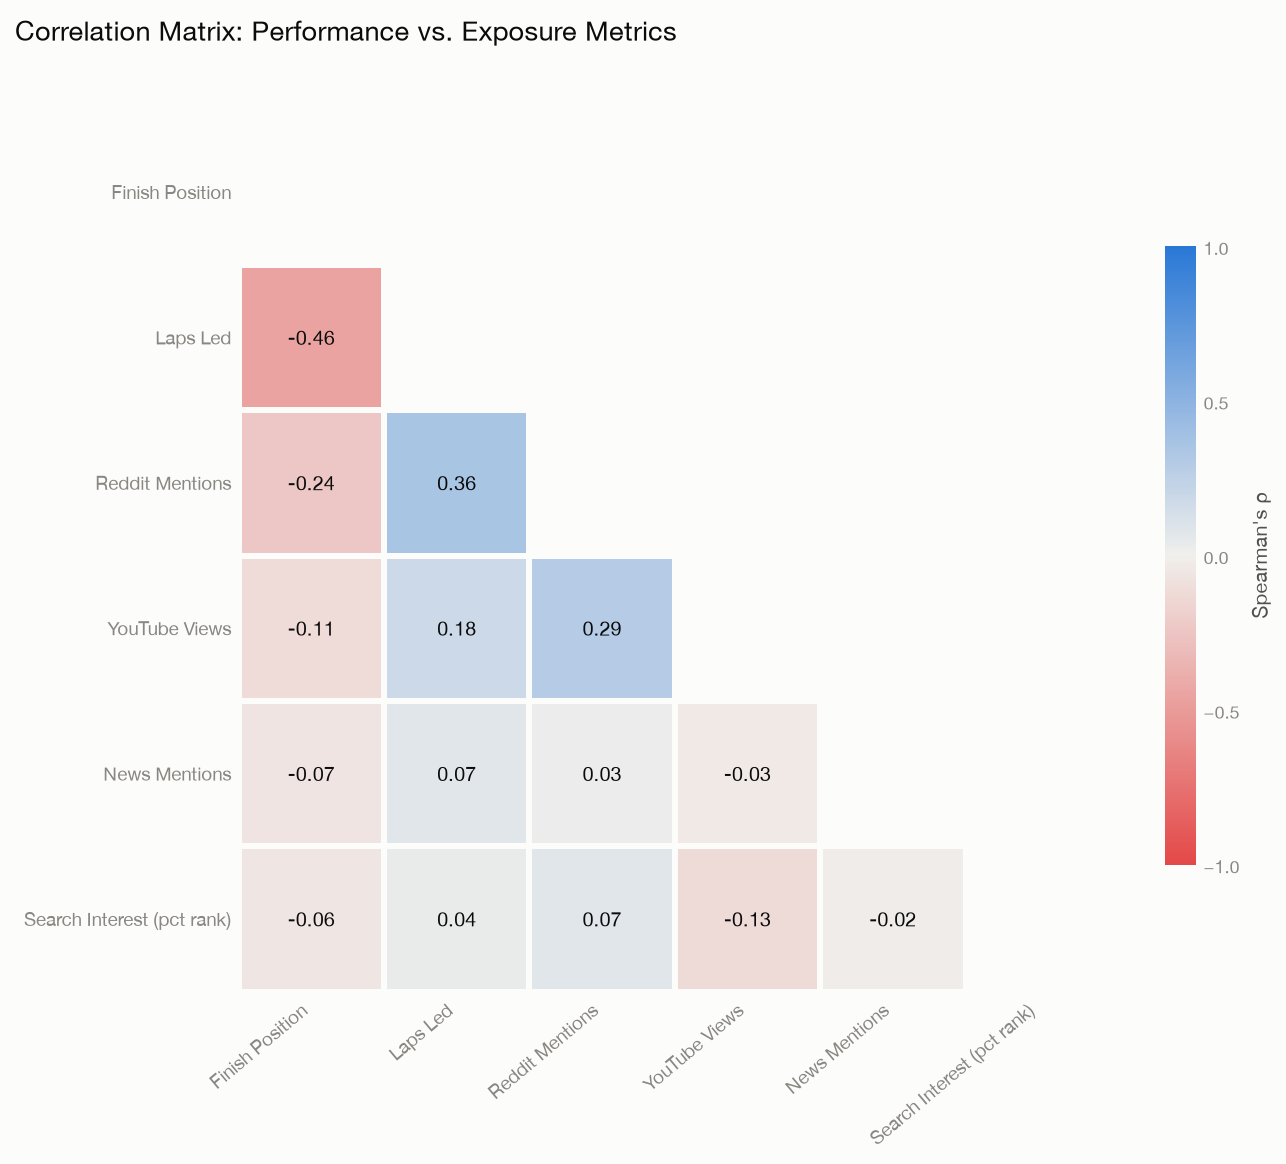

Heatmap saved to correlation_heatmap.png


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Diverging pair on the same design tokens as the histograms above: blue/red
# poles with a neutral gray midpoint, rather than seaborn's default RdBu_r.
DIVERGING_NEG = "#e34948"  # red  (negative correlation)
DIVERGING_MID = "#f0efec"  # neutral gray (near zero)
DIVERGING_POS = "#2a78d6"  # blue (positive correlation)
diverging_cmap = mcolors.LinearSegmentedColormap.from_list(
    "diverging_blue_red", [DIVERGING_NEG, DIVERGING_MID, DIVERGING_POS]
)

# Human-readable labels instead of raw column names
label_map = {
    'finish_position': 'Finish Position',
    'laps_led': 'Laps Led',
    'reddit_mention_count': 'Reddit Mentions',
    'youtube_total_view_count': 'YouTube Views',
    'youtube_total_like_count': 'YouTube Likes',
    'youtube_total_comment_count': 'YouTube Comments',
    'news_total_mentions': 'News Mentions',
    'search_interest_pctrank': 'Search Interest (pct rank)',
}
display_matrix = correlation_matrix.rename(index=label_map, columns=label_map)

# The matrix is symmetric and the diagonal is always 1.0 — mask the upper
# triangle so only the non-redundant half is shown.
mask = np.triu(np.ones_like(display_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7.5), dpi=150)
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

sns.heatmap(
    display_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap=diverging_cmap,
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=2,
    linecolor=SURFACE,
    cbar_kws={'shrink': 0.7, 'label': "Spearman's ρ", 'ticks': [-1, -0.5, 0, 0.5, 1]},
    annot_kws={'fontsize': 9.5},
    ax=ax
)

# annotate() only draws text for unmasked cells, in row-major order — walk the
# same order to give each cell dark ink on pale fills, light ink on saturated ones
n = display_matrix.shape[0]
text_colors = [
    SURFACE if abs(display_matrix.values[i, j]) > 0.55 else INK_PRIMARY
    for i in range(n) for j in range(n) if not mask[i, j]
]
for text, color in zip(ax.texts, text_colors):
    text.set_color(color)

ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', color=INK_MUTED, fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, color=INK_MUTED, fontsize=9)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(length=0)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=8.5, colors=INK_MUTED, length=0)
cbar.set_label("Spearman's ρ", color=INK_SECONDARY, fontsize=9.5)
cbar.outline.set_visible(False)

fig.suptitle('Correlation Matrix: Performance vs. Exposure Metrics', fontsize=13,
             color=INK_PRIMARY, x=0.01, ha='left', y=1.02)
fig.tight_layout()
plt.savefig('data/plots/correlation_heatmap.png', dpi=150, facecolor=SURFACE, bbox_inches='tight')
plt.show()

print("Heatmap saved to correlation_heatmap.png")

In [13]:
# power analysis:
import pingouin as pg 
from itertools import combinations

def find_power(r:float, n=223, alpha=0.05, target_power=0.8)->float:
    power = pg.power_corr(r=r, n=n, alpha=alpha)
    mde = pg.power_corr(n=n,power=target_power,alpha=alpha)
    print(f"Power: {power}, Minimum Detectable Effect Size: {mde}")
    return power, mde

# a conventional power threshold:
TARGET_POWER = 0.8
SIGNIFICANCE_LEVEL = 0.05

power_results = []
for var1, var2 in combinations(correlation_matrix.columns, 2):
    clean_data = df[[var1, var2]].dropna()
    n = len(clean_data)
    corr, pval = stats.spearmanr(clean_data[var1], clean_data[var2])
    power, mde = find_power(corr, n, SIGNIFICANCE_LEVEL, TARGET_POWER)
    
    power_results.append({
        'Variable 1': var1,
        'Variable 2': var2,
        'Correlation': corr,
        'P Value': round(pval,5),
        'N': n,
        'Power': round(power,4),
        'Minimum Detectable Effect Size': round(mde,4)
    })
    
power_df = pd.DataFrame(power_results).sort_values('Power').reset_index(drop=True)
print(power_df)



Power: 0.9999999543036109, Minimum Detectable Effect Size: 0.1863029388158742
Power: 0.9463955221875785, Minimum Detectable Effect Size: 0.1863029388158742
Power: 0.38359967373466053, Minimum Detectable Effect Size: 0.1863029388158742
Power: 0.1632202411239821, Minimum Detectable Effect Size: 0.1863029388158742
Power: 0.13858266961801172, Minimum Detectable Effect Size: 0.19145193524562104
Power: 0.9998200716220118, Minimum Detectable Effect Size: 0.1863029388158742
Power: 0.7855028262314925, Minimum Detectable Effect Size: 0.1863029388158742
Power: 0.185226483405711, Minimum Detectable Effect Size: 0.1863029388158742
Power: 0.08337526924380169, Minimum Detectable Effect Size: 0.19145193524562104
Power: 0.9946124703098002, Minimum Detectable Effect Size: 0.1863029388158742
Power: 0.07391313093113633, Minimum Detectable Effect Size: 0.1863029388158742
Power: 0.18729530681529802, Minimum Detectable Effect Size: 0.19145193524562104
Power: 0.0768932215440234, Minimum Detectable Effect Size

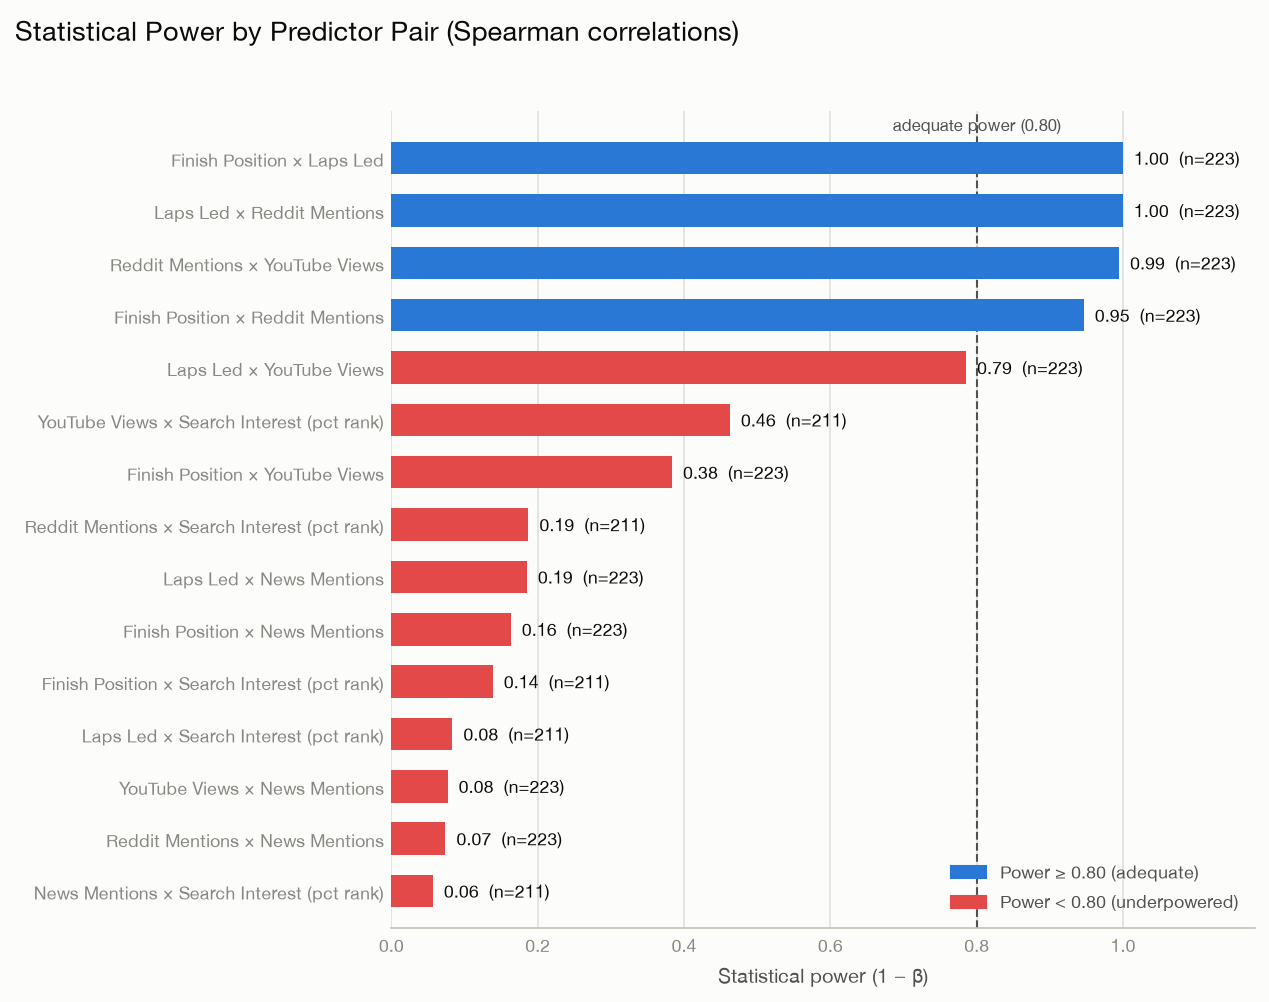

Power chart saved to power_analysis.png


In [14]:
# Power by predictor pair — status color (adequate vs underpowered) on the
# same design tokens as the histograms and heatmap above, sorted so the
# weakest evidence sits at the top and the strongest at the bottom.
POWER_ADEQUATE = FILL_EDGE      # matches the "positive" pole of the diverging pair
POWER_UNDERPOWERED = DIVERGING_NEG  # matches the "negative" pole — a status read, not a series

plot_df = power_df.sort_values('Power', ascending=True).reset_index(drop=True)
pair_labels = [
    f"{label_map.get(v1, v1)} × {label_map.get(v2, v2)}"
    for v1, v2 in zip(plot_df['Variable 1'], plot_df['Variable 2'])
]
bar_colors = [
    POWER_ADEQUATE if p >= TARGET_POWER else POWER_UNDERPOWERED
    for p in plot_df['Power']
]

fig, ax = plt.subplots(figsize=(8.5, 6.5), dpi=150)
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

y_pos = np.arange(len(plot_df))
ax.barh(y_pos, plot_df['Power'], color=bar_colors, height=0.62, zorder=3)

# reference line at the conventional adequacy threshold
ax.axvline(TARGET_POWER, color=INK_SECONDARY, linewidth=1, linestyle="--", zorder=2)
ax.set_ylim(-0.7, len(plot_df) - 0.1)
ax.text(TARGET_POWER, len(plot_df) - 0.55, "adequate power (0.80)",
        color=INK_SECONDARY, fontsize=8, ha="center", va="bottom")

# direct labels: power value + sample size, since a legend alone can't carry both
for y, power, n in zip(y_pos, plot_df['Power'], plot_df['N']):
    ax.text(power + 0.015, y, f"{power:.2f}  (n={n})",
            color=INK_PRIMARY, fontsize=8.5, va="center", ha="left")

ax.set_yticks(y_pos)
ax.set_yticklabels(pair_labels, color=INK_SECONDARY, fontsize=9)
ax.set_xlim(0, 1.18)
ax.set_xlabel("Statistical power (1 − β)", color=INK_SECONDARY, fontsize=9.5)

ax.grid(axis="x", color=GRIDLINE, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(BASELINE)
ax.tick_params(axis="both", colors=INK_MUTED, labelsize=8.5, length=0)

# legend for the status encoding — power adequacy is a category, not a magnitude
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=POWER_ADEQUATE, label=f"Power ≥ {TARGET_POWER:.2f} (adequate)"),
    plt.Rectangle((0, 0), 1, 1, color=POWER_UNDERPOWERED, label=f"Power < {TARGET_POWER:.2f} (underpowered)"),
]
ax.legend(handles=legend_handles, loc="lower right", frameon=False,
          fontsize=8.5, labelcolor=INK_SECONDARY)

fig.suptitle("Statistical Power by Predictor Pair (Spearman correlations)", fontsize=13,
             color=INK_PRIMARY, x=0.01, ha="left", y=1.02)
fig.tight_layout()
plt.savefig('data/plots/power_analysis.png', dpi=150, facecolor=SURFACE, bbox_inches='tight')
plt.show()

print("Power chart saved to power_analysis.png")

In [16]:
# Calculate correlations by sponsor
sponsor_correlations = []

for sponsor in df['primary_sponsor'].unique():
    sponsor_data = df[df['primary_sponsor'] == sponsor]

    if len(sponsor_data) >= 10:  # Need enough data points
        corr_finish_reddit, _ = stats.spearmanr(
            sponsor_data['finish_position'],
            sponsor_data['reddit_mention_count']
        )
        corr_finish_youtube, _ = stats.spearmanr(
            sponsor_data['finish_position'],
            sponsor_data['youtube_total_view_count']
        )

        sponsor_correlations.append({
            'Sponsor': sponsor,
            'Finish_vs_Reddit': round(corr_finish_reddit, 3),
            'Finish_vs_YouTube': round(corr_finish_youtube, 3)
        })

sponsor_corr_df = pd.DataFrame(sponsor_correlations)
print("\nCorrelations by Sponsor:")
print(sponsor_corr_df)


Correlations by Sponsor:
                     Sponsor  Finish_vs_Reddit  Finish_vs_YouTube
0                Busch Light             0.047             -0.128
1                    Castrol            -0.034              0.113
2        Love's Travel Stops            -0.176             -0.049
3                Progressive            -0.078              0.034
4  Cheddar's Scratch Kitchen             0.258              0.348


In [17]:
# Load your correlation results
correlation_results = pd.read_csv('correlation_results.csv')

# Filter for statistically significant correlations (p < 0.05)
significant = correlation_results[correlation_results['P-Value'] < 0.05].copy()

# Add interpretation
def interpret_correlation(row):
    corr = row['Correlation']
    if abs(corr) >= 0.7:
        strength = "Strong"
    elif abs(corr) >= 0.4:
        strength = "Moderate"
    else:
        strength = "Weak"

    direction = "negative" if corr < 0 else "positive"
    return f"{strength} {direction}"

significant['Interpretation'] = significant.apply(interpret_correlation, axis=1)

print("Statistically Significant Correlations (p < 0.05):")
print(significant.to_string(index=False))

Statistically Significant Correlations (p < 0.05):
     Variable 1                  Variable 2  Correlation  P-Value   N Significance Interpretation
finish_position        reddit_mention_count       -0.236   0.0004 223          ***  Weak negative
       laps_led        reddit_mention_count        0.356   0.0000 223          ***  Weak positive
       laps_led    youtube_total_view_count        0.183   0.0061 223          ***  Weak positive
       laps_led    youtube_total_like_count        0.132   0.0489 223           **  Weak positive
       laps_led youtube_total_comment_count        0.166   0.0129 223           **  Weak positive


In [18]:
# Find correlations that don't match expectations
# For example: is YouTube surprisingly uncorrelated with performance?

print("\nUnexpected Findings Analysis:")
print("-" * 50)

for _, row in correlation_results.iterrows():
    var1, var2 = row['Variable 1'], row['Variable 2']
    corr, pval = row['Correlation'], row['P-Value']

    # Flag unexpected patterns
    if 'Position' in var1 and corr > 0:  # Better finish should = more exposure
        print(f"UNEXPECTED: {var1} vs {var2}")
        print(f"  Positive correlation ({corr:.3f}) suggests worse finishes get more exposure")
        print(f"  Possible explanations: crashes, controversies, data issues\n")

    if 'Laps_Led' in var1 and pval > 0.10:  # Expected strong relationship
        print(f"WEAK RELATIONSHIP: {var1} vs {var2}")
        print(f"  Correlation: {corr:.3f}, P-value: {pval:.4f}")
        print(f"  Laps led may not drive visibility as expected\n")


Unexpected Findings Analysis:
--------------------------------------------------


In [19]:
# Example: Check if playoff races show different patterns
if 'Is_Playoff' in df.columns:
    playoff_corr, playoff_p = stats.pearsonr(
        df[df['Is_Playoff'] == True]['Finish_Position'],
        df[df['Is_Playoff'] == True]['Reddit_Mentions']
    )

    regular_corr, regular_p = stats.pearsonr(
        df[df['Is_Playoff'] == False]['Finish_Position'],
        df[df['Is_Playoff'] == False]['Reddit_Mentions']
    )

    print(f"Finish vs Reddit correlation:")
    print(f"  Playoff races: {playoff_corr:.3f}")
    print(f"  Regular season: {regular_corr:.3f}")